In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import scipy.constants as const

# First plot

In [2]:
data = np.genfromtxt(r'freq_vs_dc_flux.txt')

Convert the coil current into the magnetic flux of the DC SQUID $\Phi_{ext}$.  
The relationship between the current and flux is:
$$ \Phi_{ext} = M \cdot I_{coil} $$
Where $M$ is the mutual inductance between the bias coil and the SQUID loop.   
We calculate the magnetic field to a circular coil with $N$ turns and radius $R$:
$$ B = \frac{\mu_0 \cdot N \cdot I_{coil}}{2R}  $$
Where $\mu_0 = 4\pi \times 10^{-7}$ H/m.  
The magnetic flux is the magnetic field passing through the effective geometric area of the SQUID:  
$$ \Phi_{ext} = B \cdot A_{SQUID} $$

To calculate the area, we assume that the inductance scales with the dimensions of the SQUID loop:
$$L_{loop} = \mu_0 d $$

Therefore the area will be:
$$ A_{SQUID} = \left( \frac{L_{loop}}{\mu_0} \right)^2 $$

From the manual the parameters:   
Coil radius $R = 5$ mm, coil turns $N = 2000$, bare resonator
inductance $L_r = 20$ nH, and dc-SQUID loop inductance $L_{loop} = 10$ pH. 

One full modulation period occurs when the charge in flux equals one flux quantum ($\Delta \Phi = \Phi_0$):
$$ \Phi_0 = B \cdot A_{SQUID}$$
$$ \Phi_0 = \left( \frac{\mu_0 \cdot N \cdot \Delta I_{theor}}{2R} \right) A_{SQUID} $$
From the formula above we can express the modulation period:
$$ \Delta I_{theor} = \frac{2 R \cdot \Phi_0}{\mu_0 \cdot N \cdot A_{SQUID}} $$

In [3]:
mu0 = const.mu_0       # Permeability of free space
N = 2000               # Number of turns in the coil
R = 5e-3               # Radius of the coil 
phi0 = const.physical_constants['mag. flux quantum'][0]  #magnetic flux quantum
Lloop = 10e-12         # SQUID loop inductance = 10 pH
Lr = 20e-9             # Bare resonator inductance = 20 nH

A = (Lloop / mu0)**2 #area

I_theor = 2* R* phi0 / (mu0 * A * N) 
I_theor * 1e6 #Microamperes

129.92583252629169

In [4]:
current_data = data[:,0]*1e-3         #Current data from -0.200 to 0.200 microamperes, converted to Amperes                               
frequency_data = data[:,1]/(2*np.pi)  #Resonant frequency data in angular frequency

def fit_model(I_coil, Ic, wr, I_period):
    flux_norm = I_coil / I_period
    Ls = phi0 / (4 * np.pi * Ic * np.abs(np.cos(np.pi * flux_norm)))
    return wr * (1.0 + (Ls + Lloop / 4.0) / Lr) ** (-1)

initial_guesses = [1.0e-6, 1.0, 0.0003] 
bounds = ([0.1e-6, 0.5, 0.0001], [50.0e-6, 2.0, 1.0])

popt, pcov = curve_fit(fit_model, current_data, frequency_data, p0=initial_guesses, bounds=bounds)
fit_Ic, fit_wr, fit_I_period = popt

print(f"JPA's Real Critical Current (Ic): {fit_Ic * 1e6:.3f} uA")
print(f"JPA's Real Base Frequency (wr): {fit_wr:.4f} GHz")
print(f"Calibration Period (Delta I): {fit_I_period:.4f}")

JPA's Real Critical Current (Ic): 0.592 uA
JPA's Real Base Frequency (wr): 0.9388 GHz
Calibration Period (Delta I): 0.0003


In [5]:
fpump = 2 * fit_wr
print(f"JPA's Real Base Frequency (wr): {fit_wr:.4f} GHz = {fit_wr*2*np.pi:.4f} rad/s")
print(f"JPA's Pump Frequency (fpump): {fpump:.4f} GHz = {fpump*2*np.pi:.4f} rad/s")

JPA's Real Base Frequency (wr): 0.9388 GHz = 5.8984 rad/s
JPA's Pump Frequency (fpump): 1.8775 GHz = 11.7968 rad/s


What we used in the experiment was a pump frequency of $11.2062$ GHz.

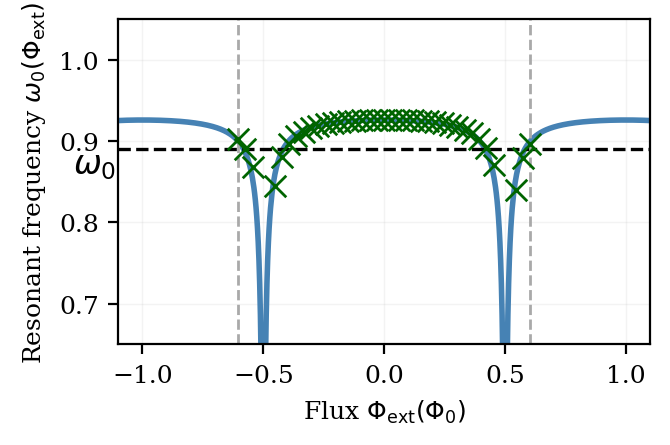

In [6]:
flux_axis_data = current_data / fit_I_period
flux_theor = np.linspace(-1.5, 1.5, 1000)

fitted_frequencies = fit_model(flux_theor * fit_I_period, fit_Ic, fit_wr, fit_I_period)

plt.style.use("fopraplot_no_latex.mplstyle")

plt.scatter(flux_axis_data, frequency_data, marker='x', color='darkgreen', s=60, zorder=3)
plt.plot(flux_theor, fitted_frequencies, color='steelblue', linewidth=2, zorder=2)

plt.axhline(y=0.89, color='black', linestyle='--', linewidth=1.2) 
plt.axvline(x=min(flux_axis_data), color='darkgray', linestyle='--', linewidth=1)       
plt.axvline(x=max(flux_axis_data), color='darkgray', linestyle='--', linewidth=1)       

plt.xlim(-1.1, 1.1)
plt.ylim(0.65, 1.05) 
plt.xlabel(r'Flux $\Phi_{\rm ext}(\Phi_0)$')
plt.ylabel(r'Resonant frequency $\omega_0(\Phi_{\rm ext})$')
plt.grid(alpha=0.15)

ax = plt.gca()
ax.text(-1.2, 0.80-0.2, r'$\omega_0$', 
        color='black', fontsize=12, 
        ha='center', va='top', 
        transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

# Second plot

In [7]:
f = open(r'S21_transmission_2.csv', 'r')
ds2 = pd.read_csv(f, comment='#', sep=';')
f.close()

f = open(r'S21_transmission_no_pump.csv', 'r')
ds_no_pump = pd.read_csv(f, comment='#', sep=';')
f.close()

freq1 =11.2062 /2 

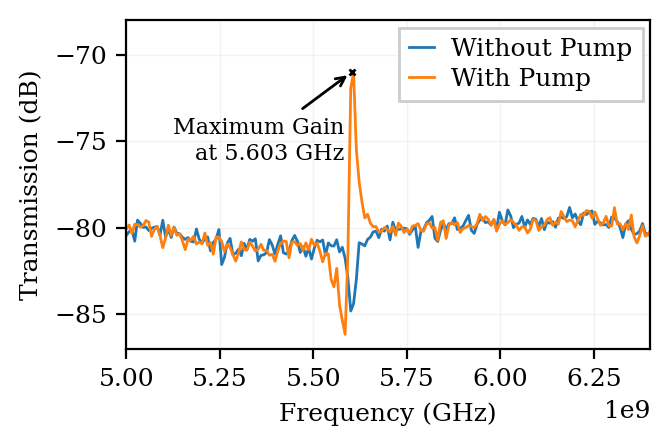

In [8]:
plt.style.use("fopraplot_no_latex.mplstyle")

fig, ax = plt.subplots()

ax.plot(ds_no_pump['freq[Hz]'], ds_no_pump['db:Trc1_S21'], label='Without Pump')
ax.plot(ds2['freq[Hz]'], ds2['db:Trc2_S21'], label='With Pump')
ax.grid(alpha=0.15)
ax.plot(freq1*1e9, -71, marker='x', color='black')

ax.annotate(
    f'Maximum Gain\nat {freq1:.3f} GHz',                    # The text you want to display
    xy=(freq1*1e9, -71),          # Arrow tip: Points exactly to your 'x' marker
    xytext=(freq1*1e9 - 0.02e9, -75),   # Text position: Offset slightly to the left and down
    arrowprops=dict(
        facecolor='black',               # Arrow fill color
        edgecolor='black',               # Arrow outline color
        arrowstyle='->',                 # Standard clean line arrow (or use '[-[' for blocks)
        connectionstyle='arc3,rad=0'     # Straight line. Use 'rad=0.2' if you want a curved arrow
    ),
    fontsize=8,
    horizontalalignment='right',         # Aligns text cleanly relative to xytext
    verticalalignment='center'
)

ax.set_xlim(5e9, 6.4e9)
ax.set_ylim(-87, -68)
ax.set(xlabel= 'Frequency (GHz)', ylabel='Transmission (dB)')
ax.legend(loc="upper right")

fig.show()